# 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
pd.options.display.max_rows=None
import warnings
warnings.filterwarnings(action='ignore')
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 날씨

In [2]:
df = pd.read_csv("data/날씨통합.csv")

#항공 데이터엔 날짜와 시간이 따로 나와있기 때문에 공백을 기준으로 컬럼 나눔
df[['날짜', '날씨측정시간']] = df['일시'].str.split(' ', n=1, expand=True) 
#일시 컬럼 포함) 필요 없는 컬럼 제거
df= df.drop(columns=['일시','1층 운형','2층 운형','3층 운형','4층 운형'])
#편리함을 위해 시간에서 :을 제외
df['날씨측정시간'] = df['날씨측정시간'].str.replace(':', '', regex=False) 

df['날짜'] = df['날짜'].str.replace('-', '', regex=False) #편리함을 위해 날짜에서 -를 제외
weather=df #데이터 혼합을 방지하기 위해 새로운 변수에 데이터셋 복사

weather.head(1)

,지점,지점명,풍향(deg),풍속(KT),순간풍속(KT),시정(m),일기현상,전운량(1/8),1층 운량(1/8),2층 운량(1/8),...,2층 운고(FT),3층 운고(FT),4층 운고(FT),기온(°C),이슬점온도(°C),해면기압(hPa),현지기압(hPa),강수량(mm),날짜,날씨측정시간
0,113,인천공항,40,3,NaN,10000,NaN,2,2.0,NaN,...,NaN,NaN,NaN,21.5,19.9,1011.4,1010.6,NaN,20220901,0000


## 항공기

In [3]:
df3 = pd.read_csv("data/항공편_전체정보.csv", encoding='cp949') #항공기 데이터셋 샘플
df3.head()

,출/도착구분,날짜,항공사,편명,출발공항코드,출발공항명,도착공항코드,도착공항명,계획시간,예상시간,출발시간,구분,현황
0,출발,20220901,아시아나항공,OZ933,ICN,인천,HAN,노이바이(하노이),00:05,23:50,00:25,화물,출발
1,출발,20220901,아시아나항공,OZ387,ICN,인천,HAN,노이바이(하노이),00:05,23:55,00:09,화물,출발
2,출발,20220901,아시아나항공,OZ967,ICN,인천,HKG,홍콩,00:05,23:45,00:23,화물,출발
3,출발,20220901,칼리타항공,K4852,ICN,인천,ANC,앵커리지,00:05,00:00,00:21,화물,출발
4,출발,20220901,대한항공,KE373,ICN,인천,PEN,페낭,00:05,00:00,00:19,화물,출발


### 지연기준 조정(~15 / 30~)

In [4]:
 #필요 없는 컬럼 삭제
df3=df3.drop(columns=['출/도착구분','출발공항코드','도착공항코드','예상시간'],axis=1) 

#국내 저가 항공사만 남김
df3 = df3[df3['항공사'].isin(['진에어', '제주항공', '티웨이항공', '에어부산'])] 
df3=df3.dropna(subset=['계획시간'])
df3=df3.dropna(subset=['출발시간'])
#화물과 기타는 제외하고 여객만 다룸
df3=df3[(df3['구분'] == '여객')]  
df3 = df3.drop("구분", axis=1) #필요 없는 변수 제거
# '계획시간'과 '출발시간'의 앞뒤 공백 제거
df3['계획시간'] = df3['계획시간'].str.strip()
df3['출발시간'] = df3['출발시간'].str.strip()


# datetime 변환 시 errors='coerce' 옵션을 사용해 변환 실패 시 NaT로 처리
df3['계획시간_dt'] = pd.to_datetime('1900-01-01 ' + df3['계획시간'], 
                                    format='%Y-%m-%d %H:%M', errors='coerce')
df3['출발시간_dt'] = pd.to_datetime('1900-01-01 ' + df3['출발시간'], 
                                    format='%Y-%m-%d %H:%M', errors='coerce')

#NaT 행 삭제
df3 = df3.dropna(subset=['출발시간_dt'])

# 조건: 계획시간이 22시 이상이고, 출발시간이 03시 미만인 경우에만 다음날 조정 대상
mask = (
    (df3['출발시간_dt'] < df3['계획시간_dt']) & 
    (df3['계획시간_dt'].dt.hour >= 22) & 
    (df3['출발시간_dt'].dt.hour < 3)
)

# 조건에 해당하는 행만 날짜 조정 (하루 추가)
df3.loc[mask, '출발시간_dt'] += pd.Timedelta(days=1)

# 두 시간의 차이를 분 단위로 계산
df3['지연분'] = (df3['출발시간_dt'] - df3['계획시간_dt']).dt.total_seconds() / 60

# 15분 초과이면 "지연", 15분 이하이면 "출발"으로 현황 업데이트
df3['현황'] = np.where(df3['지연분'] > 15, '지연', '출발')

df3 = df3.drop("출발시간_dt", axis=1) #필요 없는 변수 제거
df3 = df3.drop("계획시간_dt", axis=1) #필요 없는 변수 제거

In [5]:
df3 = df3[~((df3['지연분'] > 15) & (df3['지연분'] < 30))]
df3.head()

,날짜,항공사,편명,출발공항명,도착공항명,계획시간,출발시간,현황,지연분
52,20220901,티웨이항공,TW125,인천,다낭,07:45,07:54,출발,9.0
83,20220901,티웨이항공,TW175,인천,세부,09:15,09:28,출발,13.0
98,20220901,에어부산,BX164,인천,도쿄/나리타,10:00,10:12,출발,12.0
102,20220901,티웨이항공,TW291,인천,후쿠오카,10:05,10:18,출발,13.0
108,20220901,진에어,LJ201,인천,도쿄/나리타,10:10,10:43,지연,33.0


In [6]:
# 결과 확인
airplane_update=df3
airplane_update.head()

,날짜,항공사,편명,출발공항명,도착공항명,계획시간,출발시간,현황,지연분
52,20220901,티웨이항공,TW125,인천,다낭,07:45,07:54,출발,9.0
83,20220901,티웨이항공,TW175,인천,세부,09:15,09:28,출발,13.0
98,20220901,에어부산,BX164,인천,도쿄/나리타,10:00,10:12,출발,12.0
102,20220901,티웨이항공,TW291,인천,후쿠오카,10:05,10:18,출발,13.0
108,20220901,진에어,LJ201,인천,도쿄/나리타,10:10,10:43,지연,33.0


# 데이터 합치기 

In [7]:
# 데이터타입이 다를 경우 나오지 않기 때문에 형식 변환
airplane_update['날짜'] = airplane_update['날짜'].astype(str)
airplane_update['계획시간'] = airplane_update['계획시간'].astype(str)
weather['날짜'] = weather['날짜'].astype(str)
weather['날씨측정시간'] = weather['날씨측정시간'].astype(str)

# airplane_info에서 계획시간을 시각으로 변환 (분단위 제거) => 항공기는 출발 직전의 최신 기상 데이터를 참고할 것이고 날씨 데이터는 1시간 단위로 측정되기 때문에 분단위 고려 안 함
airplane_update['계획시간_시'] = airplane_update['계획시간'].str[:2] + '00'

# 날짜와 시간 기준으로 병합
airplane_merged = pd.merge(airplane_update, weather, left_on=['날짜', '계획시간_시'], right_on=['날짜', '날씨측정시간'], how='left')

# 결과에서 시간_시 대신 weather의 시간 컬럼을 그대로 표시
airplane_merged = airplane_merged.drop(columns=['계획시간_시'])

In [8]:
airplane_merged.head()

,날짜,항공사,편명,출발공항명,도착공항명,계획시간,출발시간,현황,지연분,지점,...,1층 운고(FT),2층 운고(FT),3층 운고(FT),4층 운고(FT),기온(°C),이슬점온도(°C),해면기압(hPa),현지기압(hPa),강수량(mm),날씨측정시간
0,20220901,티웨이항공,TW125,인천,다낭,07:45,07:54,출발,9.0,113.0,...,NaN,NaN,NaN,NaN,20.8,18.9,1013.8,1013.0,NaN,0700
1,20220901,티웨이항공,TW175,인천,세부,09:15,09:28,출발,13.0,113.0,...,20000.0,NaN,NaN,NaN,22.6,18.1,1014.6,1013.8,NaN,0900
2,20220901,에어부산,BX164,인천,도쿄/나리타,10:00,10:12,출발,12.0,113.0,...,20000.0,NaN,NaN,NaN,23.6,18.6,1015.1,1014.3,NaN,1000
3,20220901,티웨이항공,TW291,인천,후쿠오카,10:05,10:18,출발,13.0,113.0,...,20000.0,NaN,NaN,NaN,23.6,18.6,1015.1,1014.3,NaN,1000
4,20220901,진에어,LJ201,인천,도쿄/나리타,10:10,10:43,지연,33.0,113.0,...,20000.0,NaN,NaN,NaN,23.6,18.6,1015.1,1014.3,NaN,1000


# 전처리

In [9]:
airplane_merged['현황'].value_counts()

지연    31968
출발    11580
Name: 현황, dtype: int64

In [10]:
airplane_merged=airplane_merged.dropna(subset=['현황'])   #출발 혹은 지연을 뜻하는 컬럼이라 결측치 인 값은 제거

 #필요 없는 컬럼 삭제
airplane_merged=airplane_merged.drop(columns=['출발공항명','편명','계획시간','출발시간','지점','지점명','항공사', '지연분', '순간풍속(KT)'],axis=1) 

In [11]:
#필요없는 컬럼 삭제한 뒤 airplane_dropcol에 복사
airplane_dropcol = airplane_merged

### 결측치 처리

In [12]:
airplane_dropcol.isnull().sum()  #결측치 값 확인

날짜                0
도착공항명             0
현황                0
풍향(deg)          42
풍속(KT)           42
시정(m)            42
일기현상          28754
전운량(1/8)         42
1층 운량(1/8)    11697
2층 운량(1/8)    29250
3층 운량(1/8)    38344
4층 운량(1/8)    43486
1층 운고(FT)     11697
2층 운고(FT)     29250
3층 운고(FT)     38344
4층 운고(FT)     43486
기온(°C)           42
이슬점온도(°C)        42
해면기압(hPa)        42
현지기압(hPa)        42
강수량(mm)       37720
날씨측정시간           42
dtype: int64

In [13]:
airplane_dropcol['강수량(mm)']=airplane_dropcol['강수량(mm)'].fillna(0)  #강수량에 해당하는 결측치 0으로 채움

### 구름 전처리

In [14]:
print(airplane_dropcol.iloc[:, 12:16].dtypes)

1층 운고(FT)    float64
2층 운고(FT)    float64
3층 운고(FT)    float64
4층 운고(FT)    float64
dtype: object


In [15]:
airplane_dropcol=airplane_dropcol.dropna(subset=['전운량(1/8)'])
#"전운량이 "0"일 때에는 각 층별 구름은 빈칸으로 두고," (기상청날씨누리, 항공기후통게지침 피셜...)이기 때문에 결측치는 삭제...

airplane_dropcol['전운고'] = airplane_dropcol.iloc[:, 12:16].sum(axis=1)
#전체적인 구름의 고도와 전반적인 날씨 상황을 쉽게 파악하기 위해 1234층의 운고를 전운고로 통합

airplane_dropcol=airplane_dropcol.drop(columns=['1층 운량(1/8)','2층 운량(1/8)','3층 운량(1/8)','4층 운량(1/8)','1층 운고(FT)','2층 운고(FT)','3층 운고(FT)','4층 운고(FT)'],axis=1)
#운량 또한 전체적인 구름의 양으로 파악하기 위해 1234층의 운량은 삭제, 마찬가지로 운고도 동일하게 진행

col_to_move = airplane_dropcol.pop('전운고')

# 2. 맨 마지막 위치에 '전운고' 컬럼 추가 (전체 컬럼 수를 인덱스로 사용)
airplane_dropcol.insert(len(airplane_dropcol.columns), '전운고', col_to_move)

In [16]:
#결측치 제거 후 airplane_dropnull에 복사
airplane_dropnull=airplane_dropcol

### 풍향 전처리

In [17]:
# 풍향 범주화
def categorize_wind_direction(direction):
    if 0 <= direction < 90:
        return 1  #북동풍
    elif 90 <= direction < 180:
        return 2  #남동풍
    elif 180 <= direction < 270:
        return 3  #남서풍
    elif 270 <= direction <= 360:
        return 4  # 북서풍
    else:
        return np.nan  # 결측치 처리

# 풍향 데이터에 범주화 적용
airplane_dropnull['풍향'] = airplane_dropnull['풍향(deg)'].apply(categorize_wind_direction)

# 각 범주별 분포 확인
print(airplane_dropnull['풍향'].value_counts())
airplane_dropnull = airplane_dropnull.drop(columns=['풍향(deg)'], axis=1)

4    17391
3     9956
1     8369
2     7790
Name: 풍향, dtype: int64


In [18]:
airplane_deg= airplane_dropnull

### 일기현상을 안개와 황사로 나눔

In [19]:
fog_conditions = {10, 5, 41, 47, 70, 45, 43, 46, 51, 44, 42}
yellow_dust_conditions = {6, 50}

# Add 안개 and 황사 컬럼
airplane_deg['안개'] = np.where(airplane_deg['일기현상'].isin(fog_conditions), 1, 0)
airplane_deg['황사'] = np.where(airplane_deg['일기현상'].isin(yellow_dust_conditions), 1, 0)
airplane_deg=airplane_deg.drop("일기현상", axis=1) 

airplane_deg.head(5)

,날짜,도착공항명,현황,풍속(KT),시정(m),전운량(1/8),기온(°C),이슬점온도(°C),해면기압(hPa),현지기압(hPa),강수량(mm),날씨측정시간,전운고,풍향,안개,황사
0,20220901,다낭,출발,4.0,10000.0,0.0,20.8,18.9,1013.8,1013.0,0.0,0700,0.0,1,0,0
1,20220901,세부,출발,9.0,10000.0,1.0,22.6,18.1,1014.6,1013.8,0.0,0900,20000.0,1,0,0
2,20220901,도쿄/나리타,출발,8.0,10000.0,2.0,23.6,18.6,1015.1,1014.3,0.0,1000,20000.0,1,0,0
3,20220901,후쿠오카,출발,8.0,10000.0,2.0,23.6,18.6,1015.1,1014.3,0.0,1000,20000.0,1,0,0
4,20220901,도쿄/나리타,지연,8.0,10000.0,2.0,23.6,18.6,1015.1,1014.3,0.0,1000,20000.0,1,0,0


### 국내/국제선 컬럼 추가

In [367]:
# airplane_dropnull.to_excel("파일.xlsx", index=False)

In [20]:
airplane_add = airplane_deg

# 대한민국 공항 리스트
domestic_airports = ["인천", "김포", "김해", "제주", "대구", "청주", "무안", "양양","포항", "울산", "여수", "사천", "군산", "원주", "광주"]

# 새로운 변수 추가: '국내/국제선'
airplane_add['국내/국제선'] = airplane_add['도착공항명'].apply(
    lambda x: 0 if any(airport in x for airport in domestic_airports) else 1
)

airplane_add.head()

,날짜,도착공항명,현황,풍속(KT),시정(m),전운량(1/8),기온(°C),이슬점온도(°C),해면기압(hPa),현지기압(hPa),강수량(mm),날씨측정시간,전운고,풍향,안개,황사,국내/국제선
0,20220901,다낭,출발,4.0,10000.0,0.0,20.8,18.9,1013.8,1013.0,0.0,0700,0.0,1,0,0,1
1,20220901,세부,출발,9.0,10000.0,1.0,22.6,18.1,1014.6,1013.8,0.0,0900,20000.0,1,0,0,1
2,20220901,도쿄/나리타,출발,8.0,10000.0,2.0,23.6,18.6,1015.1,1014.3,0.0,1000,20000.0,1,0,0,1
3,20220901,후쿠오카,출발,8.0,10000.0,2.0,23.6,18.6,1015.1,1014.3,0.0,1000,20000.0,1,0,0,1
4,20220901,도쿄/나리타,지연,8.0,10000.0,2.0,23.6,18.6,1015.1,1014.3,0.0,1000,20000.0,1,0,0,1


In [21]:
airplane_add['국내/국제선'].value_counts()

1    43485
0       21
Name: 국내/국제선, dtype: int64

### 공휴일 컬럼 추가

In [22]:
#공휴일
# !pip install holidays
from datetime import datetime
import holidays

In [23]:
# 2. 날짜 형식 변환
airplane_add['날짜'] = pd.to_datetime(airplane_add['날짜'], format='%Y%m%d')

# 공휴일 설정
kr_holidays = holidays.KR(years=[2022, 2023, 2024])  # 여러 해를 동시에 설정

# 4.공휴일 여부 확인
airplane_add['공휴일 여부'] = airplane_add['날짜'].isin(kr_holidays).astype(int)

# 공휴일 행만 출력
airplane_add[airplane_add['공휴일 여부'] == 1]

# 주말 여부 확인 (토요일=5, 일요일=6)
airplane_add['주말 여부'] = airplane_add['날짜'].dt.dayofweek.isin([5, 6]).astype(int)

#통합
airplane_add['휴일 여부'] = airplane_add['공휴일 여부'] | airplane_add['주말 여부']
#airplane[airplane['휴일 여부'] == True].head(30)

# 주말 행만 출력
airplane_add[airplane_add['휴일 여부'] == 1].head()

,날짜,도착공항명,현황,풍속(KT),시정(m),전운량(1/8),기온(°C),이슬점온도(°C),해면기압(hPa),현지기압(hPa),강수량(mm),날씨측정시간,전운고,풍향,안개,황사,국내/국제선,공휴일 여부,주말 여부,휴일 여부
26,2022-09-03,팡라로,출발,10.0,10000.0,3.0,19.5,15.9,1015.5,1014.6,0.0,0700,25000.0,1,0,0,1,0,1,1
27,2022-09-03,세부,출발,10.0,10000.0,6.0,22.0,15.7,1015.5,1014.7,0.0,0900,23000.0,1,0,0,1,0,1,1
28,2022-09-03,도쿄/나리타,지연,8.0,10000.0,6.0,23.9,16.6,1015.3,1014.5,0.0,1000,29000.0,1,0,0,1,0,1,1
29,2022-09-03,삿포로,지연,8.0,10000.0,6.0,23.9,16.6,1015.3,1014.5,0.0,1000,29000.0,1,0,0,1,0,1,1
30,2022-09-03,도쿄/나리타,지연,8.0,10000.0,6.0,23.9,16.6,1015.3,1014.5,0.0,1000,29000.0,1,0,0,1,0,1,1


In [24]:
# 1. 날짜 단위로 중복 제거
날짜별_휴일 = airplane_add[['날짜', '휴일 여부']].drop_duplicates()

# 2. 날짜 단위로 정렬 및 그룹화
날짜별_휴일 = 날짜별_휴일.sort_values(by='날짜').reset_index(drop=True)
날짜별_휴일['휴일 그룹'] = (
    날짜별_휴일['휴일 여부'] & ~날짜별_휴일['휴일 여부'].shift(1, fill_value=False)
).cumsum()

# 3. 남은 휴일 수 계산 (transform 사용)
날짜별_휴일['남은 휴일 수'] = 날짜별_휴일.groupby('휴일 그룹')['휴일 여부'].transform(
    lambda group: group[::-1].cumsum()[::-1]
)

# 4. 원래 데이터에 결합
airplane_add = airplane_add.merge(날짜별_휴일[['날짜', '남은 휴일 수']], on='날짜', how='left')

In [25]:
# v풍향 컬럼 원-핫 인코딩
airplane_encoded = pd.get_dummies(airplane_add, columns=['풍향'], prefix='풍향')

In [26]:
# 컬럼명 변경
airplane_encoded = airplane_encoded.rename(columns={
    '풍향_1': '풍향_NE',
    '풍향_2': '풍향_SE',
    '풍향_3': '풍향_SW',
    '풍향_4': '풍향_NW'
})

# 변경된 컬럼 확인
print(airplane_encoded.head())

          날짜   도착공항명  현황  풍속(KT)    시정(m)  전운량(1/8)  기온(°C)  이슬점온도(°C)  \
0 2022-09-01      다낭  출발     4.0  10000.0       0.0    20.8       18.9   
1 2022-09-01      세부  출발     9.0  10000.0       1.0    22.6       18.1   
2 2022-09-01  도쿄/나리타  출발     8.0  10000.0       2.0    23.6       18.6   
3 2022-09-01    후쿠오카  출발     8.0  10000.0       2.0    23.6       18.6   
4 2022-09-01  도쿄/나리타  지연     8.0  10000.0       2.0    23.6       18.6   

   해면기압(hPa)  현지기압(hPa)  ...  황사 국내/국제선  공휴일 여부  주말 여부  휴일 여부  남은 휴일 수  풍향_NE  \
0     1013.8     1013.0  ...   0      1       0      0      0        0      1   
1     1014.6     1013.8  ...   0      1       0      0      0        0      1   
2     1015.1     1014.3  ...   0      1       0      0      0        0      1   
3     1015.1     1014.3  ...   0      1       0      0      0        0      1   
4     1015.1     1014.3  ...   0      1       0      0      0        0      1   

   풍향_SE  풍향_SW  풍향_NW  
0      0      0      0  
1      0      0   

In [27]:
# Boolean 값을 0과 1로 변환
airplane_encoded[['풍향_NE', '풍향_SE', '풍향_SW', '풍향_NW']] = airplane_encoded[['풍향_NE', '풍향_SE', '풍향_SW', '풍향_NW']].astype(int)

# 변환 결과 확인
print(airplane_encoded.head())

          날짜   도착공항명  현황  풍속(KT)    시정(m)  전운량(1/8)  기온(°C)  이슬점온도(°C)  \
0 2022-09-01      다낭  출발     4.0  10000.0       0.0    20.8       18.9   
1 2022-09-01      세부  출발     9.0  10000.0       1.0    22.6       18.1   
2 2022-09-01  도쿄/나리타  출발     8.0  10000.0       2.0    23.6       18.6   
3 2022-09-01    후쿠오카  출발     8.0  10000.0       2.0    23.6       18.6   
4 2022-09-01  도쿄/나리타  지연     8.0  10000.0       2.0    23.6       18.6   

   해면기압(hPa)  현지기압(hPa)  ...  황사 국내/국제선  공휴일 여부  주말 여부  휴일 여부  남은 휴일 수  풍향_NE  \
0     1013.8     1013.0  ...   0      1       0      0      0        0      1   
1     1014.6     1013.8  ...   0      1       0      0      0        0      1   
2     1015.1     1014.3  ...   0      1       0      0      0        0      1   
3     1015.1     1014.3  ...   0      1       0      0      0        0      1   
4     1015.1     1014.3  ...   0      1       0      0      0        0      1   

   풍향_SE  풍향_SW  풍향_NW  
0      0      0      0  
1      0      0   

In [28]:
# airplane_encoded = airplane_add
airplane_encoded = airplane_encoded.drop(columns=['날짜','도착공항명', '날씨측정시간', '공휴일 여부','주말 여부']) #필요 없는 컬럼 삭제
airplane_encoded.head()

,현황,풍속(KT),시정(m),전운량(1/8),기온(°C),이슬점온도(°C),해면기압(hPa),현지기압(hPa),강수량(mm),전운고,안개,황사,국내/국제선,휴일 여부,남은 휴일 수,풍향_NE,풍향_SE,풍향_SW,풍향_NW
0,출발,4.0,10000.0,0.0,20.8,18.9,1013.8,1013.0,0.0,0.0,0,0,1,0,0,1,0,0,0
1,출발,9.0,10000.0,1.0,22.6,18.1,1014.6,1013.8,0.0,20000.0,0,0,1,0,0,1,0,0,0
2,출발,8.0,10000.0,2.0,23.6,18.6,1015.1,1014.3,0.0,20000.0,0,0,1,0,0,1,0,0,0
3,출발,8.0,10000.0,2.0,23.6,18.6,1015.1,1014.3,0.0,20000.0,0,0,1,0,0,1,0,0,0
4,지연,8.0,10000.0,2.0,23.6,18.6,1015.1,1014.3,0.0,20000.0,0,0,1,0,0,1,0,0,0


In [29]:
airplane_encoded.isnull().sum()

현황           0
풍속(KT)       0
시정(m)        0
전운량(1/8)     0
기온(°C)       0
이슬점온도(°C)    0
해면기압(hPa)    0
현지기압(hPa)    0
강수량(mm)      0
전운고          0
안개           0
황사           0
국내/국제선       0
휴일 여부        0
남은 휴일 수      0
풍향_NE        0
풍향_SE        0
풍향_SW        0
풍향_NW        0
dtype: int64

In [30]:
airplane = airplane_encoded

In [31]:
#컬럼명 영문 변경
column_mapping = {
    "현황": "DelayStatus",
    "풍속(KT)": "WindSpeed_KT", 
    "시정(m)": "Visibility_m", 
    "전운량(1/8)": "TotalCloudCover",
    "기온(°C)": "Temp_C",  
    "이슬점온도(°C)": "DewP_C", 
    "해면기압(hPa)": "SLP_hPa", #SeaLevelPressure_hPa
    "현지기압(hPa)": "LP_hPa", #LocalPressure_hPa
    "강수량(mm)": "Precipitation_mm",
    "전운고": "CBH_m", #CloudBaseHeight_m
    "안개": "Fog", 
    "황사": "YellowDust", 
    "국내/국제선": "Dom/Int", #Domestic or International 
    "휴일 여부": "IsHoliday",
    "남은 휴일 수": "LeftHolidays",
    "풍향_NE": "WindDirection_NE",  
    "풍향_SE": "WindDirection_SE", 
    "풍향_SW": "WindDirection_SW",  
    "풍향_NW": "WindDirection_NW"
}

# 컬럼명 변경
airplane.rename(columns=column_mapping, inplace=True)

# 결과 확인
print(airplane.columns)


Index(['DelayStatus', 'WindSpeed_KT', 'Visibility_m', 'TotalCloudCover',
       'Temp_C', 'DewP_C', 'SLP_hPa', 'LP_hPa', 'Precipitation_mm', 'CBH_m',
       'Fog', 'YellowDust', 'Dom/Int', 'IsHoliday', 'LeftHolidays',
       'WindDirection_NE', 'WindDirection_SE', 'WindDirection_SW',
       'WindDirection_NW'],
      dtype='object')


In [32]:
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report,confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [34]:
airplane['DelayStatus'] = airplane['DelayStatus'].map({'출발': 0, '지연': 1})
airplane.head()

,DelayStatus,WindSpeed_KT,Visibility_m,TotalCloudCover,Temp_C,DewP_C,SLP_hPa,LP_hPa,Precipitation_mm,CBH_m,Fog,YellowDust,Dom/Int,IsHoliday,LeftHolidays,WindDirection_NE,WindDirection_SE,WindDirection_SW,WindDirection_NW
0,0,4.0,10000.0,0.0,20.8,18.9,1013.8,1013.0,0.0,0.0,0,0,1,0,0,1,0,0,0
1,0,9.0,10000.0,1.0,22.6,18.1,1014.6,1013.8,0.0,20000.0,0,0,1,0,0,1,0,0,0
2,0,8.0,10000.0,2.0,23.6,18.6,1015.1,1014.3,0.0,20000.0,0,0,1,0,0,1,0,0,0
3,0,8.0,10000.0,2.0,23.6,18.6,1015.1,1014.3,0.0,20000.0,0,0,1,0,0,1,0,0,0
4,1,8.0,10000.0,2.0,23.6,18.6,1015.1,1014.3,0.0,20000.0,0,0,1,0,0,1,0,0,0


In [35]:
airplane.shape

(43506, 19)

In [36]:
airplane['DelayStatus'].value_counts()

1    31949
0    11557
Name: DelayStatus, dtype: int64

In [37]:
stats_table = airplane.describe().loc[['mean', 'std', 'min', 'max']].T
stats_table.columns = ['Mean', 'Std', 'Min', 'Max']  # 컬럼명 변경

# 출력
print(stats_table)

                         Mean          Std    Min      Max
DelayStatus          0.734358     0.441679    0.0      1.0
WindSpeed_KT         7.717510     4.414060    0.0     34.0
Visibility_m      8814.307222  2301.882956   50.0  10000.0
TotalCloudCover      3.903577     3.118288    0.0      8.0
Temp_C              14.152133    11.150161  -15.2     35.1
DewP_C               8.783634    12.225607  -25.1     27.3
SLP_hPa           1016.178054     8.962589  993.3   1039.7
LP_hPa            1015.343502     8.928737  992.6   1038.8
Precipitation_mm     0.187928     1.631268    0.0     61.9
CBH_m             9141.267871  9031.457783    0.0  49000.0
Fog                  0.206615     0.404882    0.0      1.0
YellowDust           0.015814     0.124757    0.0      1.0
Dom/Int              0.999517     0.021965    0.0      1.0
IsHoliday            0.320071     0.466509    0.0      1.0
LeftHolidays         0.523905     0.873700    0.0      6.0
WindDirection_NE     0.192364     0.394162    0.0      1

In [38]:
airplane.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 43506 entries, 0 to 43505
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   DelayStatus       43506 non-null  int64  
 1   WindSpeed_KT      43506 non-null  float64
 2   Visibility_m      43506 non-null  float64
 3   TotalCloudCover   43506 non-null  float64
 4   Temp_C            43506 non-null  float64
 5   DewP_C            43506 non-null  float64
 6   SLP_hPa           43506 non-null  float64
 7   LP_hPa            43506 non-null  float64
 8   Precipitation_mm  43506 non-null  float64
 9   CBH_m             43506 non-null  float64
 10  Fog               43506 non-null  int32  
 11  YellowDust        43506 non-null  int32  
 12  Dom/Int           43506 non-null  int64  
 13  IsHoliday         43506 non-null  int32  
 14  LeftHolidays      43506 non-null  int32  
 15  WindDirection_NE  43506 non-null  int32  
 16  WindDirection_SE  43506 non-null  int32 

# 모델학습

## 1) 밸런싱 전

In [40]:
#트레이닝 셋트와 테스트 셋트로 데이터 구분(여기서는 7:3으로 구분)
X = np.array(airplane.drop(columns=['DelayStatus']))
y = np.array(airplane['DelayStatus'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
print("X_train 크기:", X_train.shape)
print("y_train 크기:", y_train.shape)
print("X_test 크기:", X_test.shape)
print("y_test 크기:", y_test.shape)

X_train 크기: (30454, 18)
y_train 크기: (30454,)
X_test 크기: (13052, 18)
y_test 크기: (13052,)


In [43]:
# 성능 평가 함수
def evaluate_model(X_train, y_train, X_test, y_test, class_weight=None):
    accuracy_scores = []
    f1_scores = []
    best_f1 = 0
    patience = 50
    no_improve_count = 0

    # 초기 모델 생성
    rf = RandomForestClassifier(n_estimators=10, warm_start=True, random_state=0, n_jobs=-1, class_weight=class_weight)

    for n in range(10, 300, 5):
        rf.set_params(n_estimators=n)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')

        accuracy_scores.append(acc)
        f1_scores.append(f1)

        if f1 > best_f1:
            best_f1 = f1
            best_n = n
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= patience:
            break

    # 최적의 모델 학습
    rf_best = RandomForestClassifier(n_estimators=best_n, random_state=0, n_jobs=-1, class_weight=class_weight)
    rf_best.fit(X_train, y_train)
    y_pred_best = rf_best.predict(X_test)

    # 최적 모델 성능 평가
    final_acc = accuracy_score(y_test, y_pred_best)
    final_f1 = f1_score(y_test, y_pred_best, average='weighted')
    report = classification_report(y_test, y_pred_best)
    

    return best_n, final_acc, final_f1, report, rf, y_pred_best

In [45]:
# 1) 기본 모델
print("\n1) 기본 모델(밸런싱X)")
best_n, final_acc, final_f1, report, rf, y_pred_best = evaluate_model(X_train, y_train, X_test, y_test)
# rf_best = rf
# y_pred_rf = y_pred_best 
print(f"🎯 Accuracy: {final_acc:.3f}, F1 Score: {final_f1:.3f}\n📊 성능 평가 보고서:\n{report}")


1) 기본 모델(밸런싱X)
🎯 Accuracy: 0.784, F1 Score: 0.779
📊 성능 평가 보고서:
              precision    recall  f1-score   support

           0       0.62      0.53      0.57      3530
           1       0.83      0.88      0.86      9522

    accuracy                           0.78     13052
   macro avg       0.73      0.70      0.71     13052
weighted avg       0.78      0.78      0.78     13052



In [46]:
# 2) 클래스 가중치 적용
print("\n2) 클래스 가중치 적용 모델")
best_n, final_acc, final_f1, report, rf, y_pred_best = evaluate_model(X_train, y_train, X_test, y_test, class_weight='balanced')
# rf_best_weighted = rf
# y_pred_rf_weighted = y_pred_best
print(f"🎯 Accuracy: {final_acc:.3f}, F1 Score: {final_f1:.3f}\n📊 성능 평가 보고서:\n{report}")


2) 클래스 가중치 적용 모델
🎯 Accuracy: 0.771, F1 Score: 0.775
📊 성능 평가 보고서:
              precision    recall  f1-score   support

           0       0.57      0.63      0.60      3530
           1       0.86      0.82      0.84      9522

    accuracy                           0.77     13052
   macro avg       0.71      0.73      0.72     13052
weighted avg       0.78      0.77      0.77     13052



In [47]:
# 3) 오버샘플링 (SMOTE)
print("\n3) 오버샘플링 모델")
sm = SMOTE(random_state=0)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train)
best_n, final_acc, final_f1, report, rf, y_pred_best = evaluate_model(X_train_balanced, y_train_balanced, X_test, y_test)
# rf_best_balanced = rf
# y_pred_rf_balanced = y_pred_best
print(f"🎯 Accuracy: {final_acc:.3f}, F1 Score: {final_f1:.3f}\n📊 성능 평가 보고서:\n{report}")


3) 오버샘플링 모델
🎯 Accuracy: 0.781, F1 Score: 0.780
📊 성능 평가 보고서:
              precision    recall  f1-score   support

           0       0.60      0.58      0.59      3530
           1       0.85      0.86      0.85      9522

    accuracy                           0.78     13052
   macro avg       0.72      0.72      0.72     13052
weighted avg       0.78      0.78      0.78     13052



In [48]:
# 4) 언더샘플링
print("\n4) 언더샘플링 모델")
rus = RandomUnderSampler(random_state=0)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)
best_n, final_acc, final_f1, report, rf, y_pred_best = evaluate_model(X_train_under, y_train_under, X_test, y_test)
# rf_best_under = rf
# y_pred_rf_under = y_pred_best
print(f"🎯 Accuracy: {final_acc:.3f}, F1 Score: {final_f1:.3f}\n📊 성능 평가 보고서:\n{report}")


4) 언더샘플링 모델
🎯 Accuracy: 0.727, F1 Score: 0.741
📊 성능 평가 보고서:
              precision    recall  f1-score   support

           0       0.50      0.75      0.60      3530
           1       0.89      0.72      0.79      9522

    accuracy                           0.73     13052
   macro avg       0.69      0.73      0.70     13052
weighted avg       0.78      0.73      0.74     13052



In [49]:
print("\n5) K-Fold 교차검증 (언더샘플링)")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
accuracy_list = []
report_list = []

# 폴드별 모델과 테스트 데이터 저장 리스트
models_list = []
X_test_list = []
y_test_list = []

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # 언더샘플링 적용
    rus = RandomUnderSampler(random_state=0)
    X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

    # 모델 학습
    model = RandomForestClassifier(n_estimators=best_n, random_state=0)
    model.fit(X_train_under, y_train_under)

    # 예측 및 평가
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    accuracy_list.append(acc)
    report_list.append(report)

    # 각 폴드의 모델과 테스트 데이터 저장
    models_list.append(model)
    X_test_list.append(X_test)
    y_test_list.append(y_test)

# 마지막 폴드의 모델과 예측 결과 저장
rf_best_kfold = models_list[-1]
X_test_kfold = X_test_list[-1]
y_test_kfold = y_test_list[-1]
y_pred_rf_kfold = model.predict(X_test_kfold)

# 최종 평균 정확도 출력
print("📌 평균 정확도: {:.4f}".format(np.mean(accuracy_list)))
print("📊 마지막 폴드의 성능 평가:\n", report_list[-1])


5) K-Fold 교차검증 (언더샘플링)
📌 평균 정확도: 0.7307
📊 마지막 폴드의 성능 평가:
               precision    recall  f1-score   support

           0       0.50      0.75      0.60      2311
           1       0.89      0.73      0.80      6390

    accuracy                           0.73      8701
   macro avg       0.69      0.74      0.70      8701
weighted avg       0.78      0.73      0.75      8701



In [50]:
# !pip install lightgbm
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report

# 기존 언더샘플링 데이터 사용
X_train_resampled, y_train_resampled = X_train_under, y_train_under
X_test_resampled, y_test_resampled = X_test, y_test  # 테스트 데이터는 그대로 유지

# LightGBM 데이터셋 준비
train_data = lgb.Dataset(X_train_resampled, label=y_train_resampled)
test_data = lgb.Dataset(X_test_resampled, label=y_test_resampled)

# 파라미터 설정
params = {
    'objective': 'binary',          # 이진 분류
    'metric': 'auc',                # 평가 지표
    'boosting_type': 'gbdt',        # 부스팅 타입
    'learning_rate': 0.1,           # 학습률
    'num_leaves': 31,               # 리프 노드 개수
    'max_depth': -1,                # 트리의 최대 깊이 (제한 없음)
    'seed': 0,                      # 랜덤 시드 설정
    'min_child_weight': 1,          # 리프 노드 최소 가중치 합
    'subsample': 0.8,               # 샘플링 비율
    'colsample_bytree': 0.8,        # 컬럼 샘플링 비율
}

# 모델 학습
model_resampled = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# 예측
y_pred_proba = model_resampled.predict(X_test_resampled, num_iteration=model_resampled.best_iteration)
y_pred_resampled = (y_pred_proba > 0.5).astype(int)

# 정확도 평가
accuracy = accuracy_score(y_test_resampled, y_pred_resampled)
print('LightGBM 정확도:', accuracy)

# 성능 평가 보고서
report = classification_report(y_test_resampled, y_pred_resampled)
print("📊 lightGBM 언더샘플링 후 결과:\n", report)

[LightGBM] [Info] Number of positive: 9246, number of negative: 9246
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004370 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1369
[LightGBM] [Info] Number of data points in the train set: 18492, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[981]	training's auc: 0.958013	valid_1's auc: 0.793478
LightGBM 정확도: 0.7203769681645787
📊 lightGBM 언더샘플링 후 결과:
               precision    recall  f1-score   support

           0       0.48      0.75      0.59      2311
           1       0.89      0.71      0.79      6390

    accuracy                           0.72      8701
   macro avg       0.68      0.73      0.69      8701
weigh

In [51]:
# !pip install lightgbm xgboost
from xgboost import XGBClassifier
# 언더샘플링된 데이터로 모델 학습
xgb_clf_under = XGBClassifier(
n_estimators=100, learning_rate=0.1, max_depth=5, random_state=0, use_label_encoder=False, eval_metric='logloss'
)

xgb_clf_under.fit(
    X_train_under, 
    y_train_under, 
    eval_set=[(X_test, y_test)], 
    verbose=False
)

y_pred_under = xgb_clf_under.predict(X_test)

# 정확도 및 성능 평가
accuracy_under = accuracy_score(y_test, y_pred_under)
print(f"XGBoost 정확도: {accuracy_under:.3f}")

report_under = classification_report(y_test, y_pred_under)
print("📊 언더샘플링 데이터셋 성능 평가 보고서:\n", report_under)


XGBoost 정확도: 0.625
📊 언더샘플링 데이터셋 성능 평가 보고서:
               precision    recall  f1-score   support

           0       0.39      0.74      0.51      2311
           1       0.86      0.58      0.70      6390

    accuracy                           0.62      8701
   macro avg       0.63      0.66      0.60      8701
weighted avg       0.74      0.62      0.65      8701



# 모델해석

In [52]:
import seaborn as sns
# 변수 중요도 시각화 함수
def plot_feature_importance(model, feature_names, title):
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(6, 8))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title(f'Feature Importance - {title}')
    plt.gca().invert_yaxis()
    plt.show()

#     print(f"\n변수 중요도 ({title}):")
#     print(importance_df)

# 오차 행렬 시각화 함수
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
    plt.title(f'Confusion Matrix - {title}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

#     print(f"\n오차 행렬 ({title}):\n", cm)

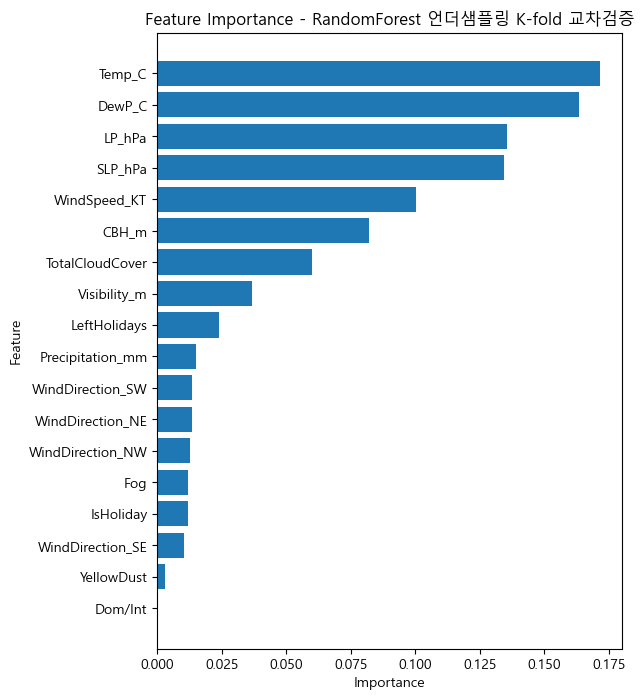

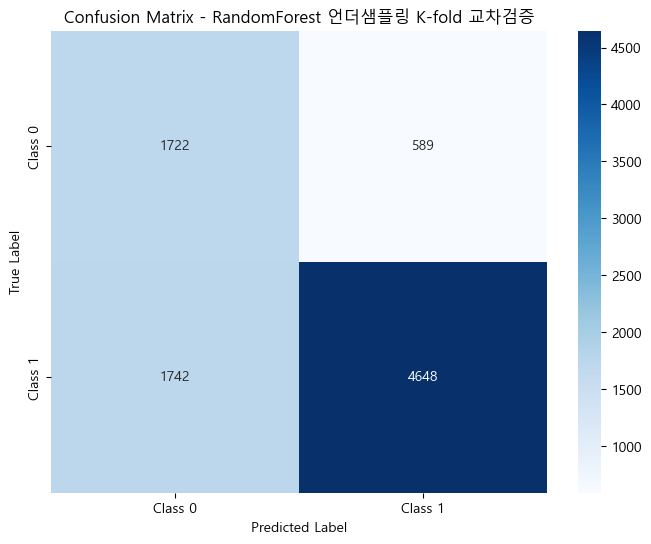

In [54]:
# 5. k-fold 적용 모델의 변수중요도
plot_feature_importance(rf_best_kfold, airplane.drop(columns=['DelayStatus']).columns, 'RandomForest 언더샘플링 K-fold 교차검증')
plot_confusion_matrix(y_test, y_pred_rf_kfold, 'RandomForest 언더샘플링 K-fold 교차검증')

### 상관관계

현황 컬럼과 나머지 컬럼 간 상관계수:
DelayStatus         1.000000
TotalCloudCover     0.102666
WindDirection_SW    0.078631
WindSpeed_KT        0.075790
Precipitation_mm    0.046022
DewP_C              0.035964
WindDirection_SE    0.022444
CBH_m               0.013851
Temp_C              0.010345
Dom/Int            -0.010848
LeftHolidays       -0.024197
YellowDust         -0.024711
IsHoliday          -0.026321
Visibility_m       -0.028210
WindDirection_NW   -0.030197
Fog                -0.038837
SLP_hPa            -0.044238
LP_hPa             -0.044337
WindDirection_NE   -0.068108
Name: DelayStatus, dtype: float64


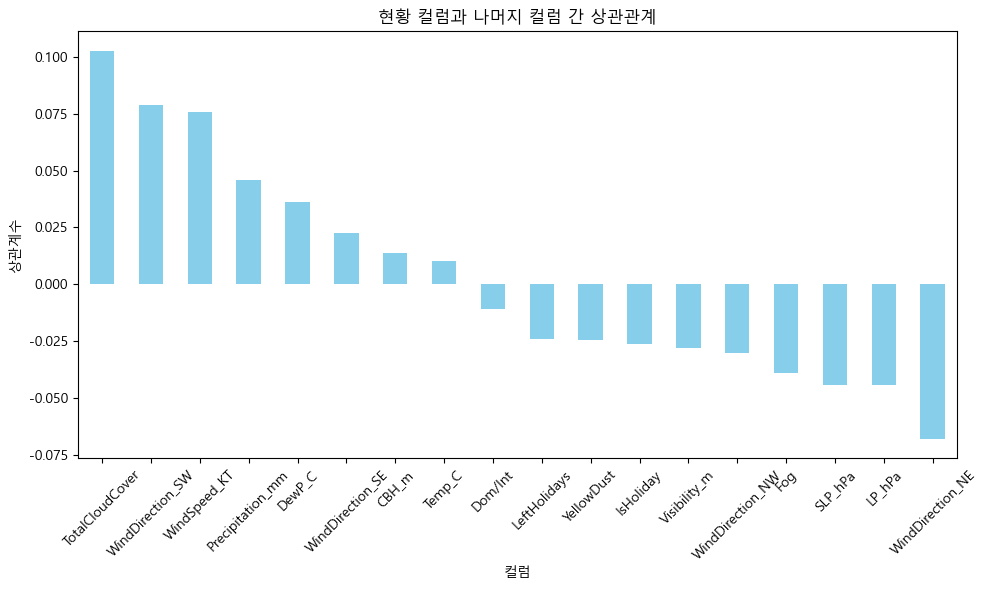

In [57]:
# 숫자형 컬럼만 선택 (현황 포함)
numeric_data = airplane.select_dtypes(include=['float64', 'int32', 'int64', 'uint8'])

# '현황' 컬럼과 나머지 컬럼 간 상관계수 계산
correlation_with_status = numeric_data.corr()['DelayStatus'].sort_values(ascending=False)

# 결과 출력
print("현황 컬럼과 나머지 컬럼 간 상관계수:")
print(correlation_with_status)

# 시각화: 막대 그래프
plt.figure(figsize=(10, 6))
correlation_with_status.drop('DelayStatus').plot(kind='bar', color='skyblue')  # 현황 자기 자신은 제외
plt.title('현황 컬럼과 나머지 컬럼 간 상관관계')
plt.ylabel('상관계수')
plt.xlabel('컬럼')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [58]:
import shap

In [59]:
# X_test_kfold를 DataFrame으로 변환 (피처 이름 포함)
X_test_kfold_df = pd.DataFrame(X_test_kfold, columns=airplane.drop(columns=['DelayStatus']).columns)

# TreeExplainer 초기화
explainer = shap.TreeExplainer(rf_best_kfold, approximate=False)

# SHAP 값 계산
shap_values = explainer.shap_values(X_test_kfold_df)

print(f"입력 데이터 차원: {X_test_kfold_df.shape}")
# SHAP 값 차원 확인
print(f"SHAP 값 차원 (샘플 수, 피처 수, 클래스 수): {shap_values.shape}")

# 클래스별 SHAP 값 차원 확인
print(f"출발 클래스 SHAP 값 차원: {shap_values[:, :, 0].shape}")
print(f"지연 클래스 SHAP 값 차원: {shap_values[:, :, 1].shape}")


입력 데이터 차원: (8701, 18)
SHAP 값 차원 (샘플 수, 피처 수, 클래스 수): (8701, 18, 2)
출발 클래스 SHAP 값 차원: (8701, 18)
지연 클래스 SHAP 값 차원: (8701, 18)


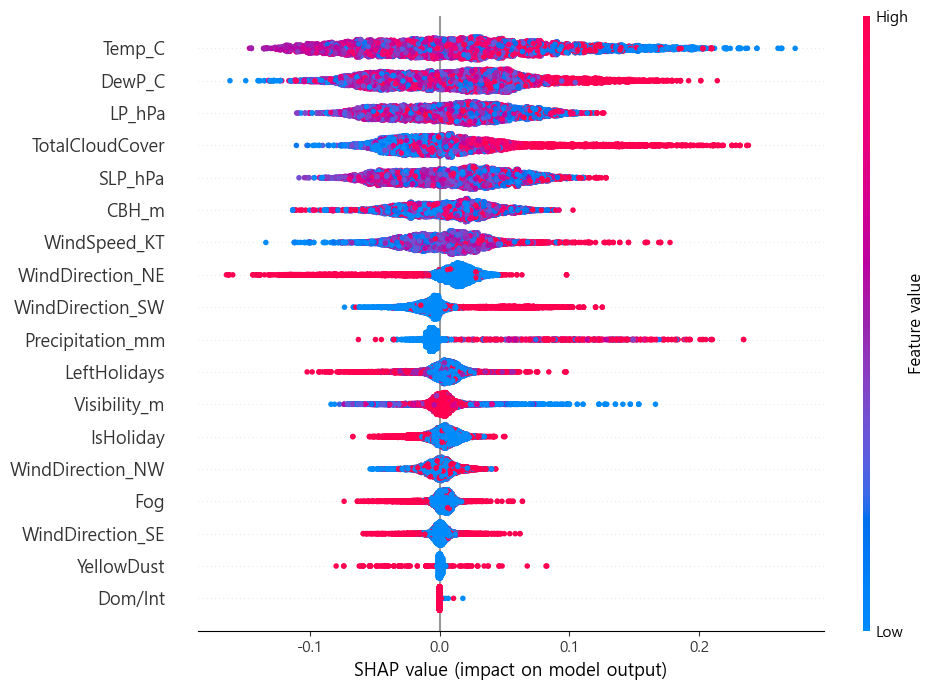

In [61]:
# SHAP Summary Plot (지연 클래스 전체)
shap.summary_plot(shap_values[:, :, 1], X_test_kfold_df, plot_size=(10, 7))

Class 0 (출발)에 대한 SHAP Force Plot


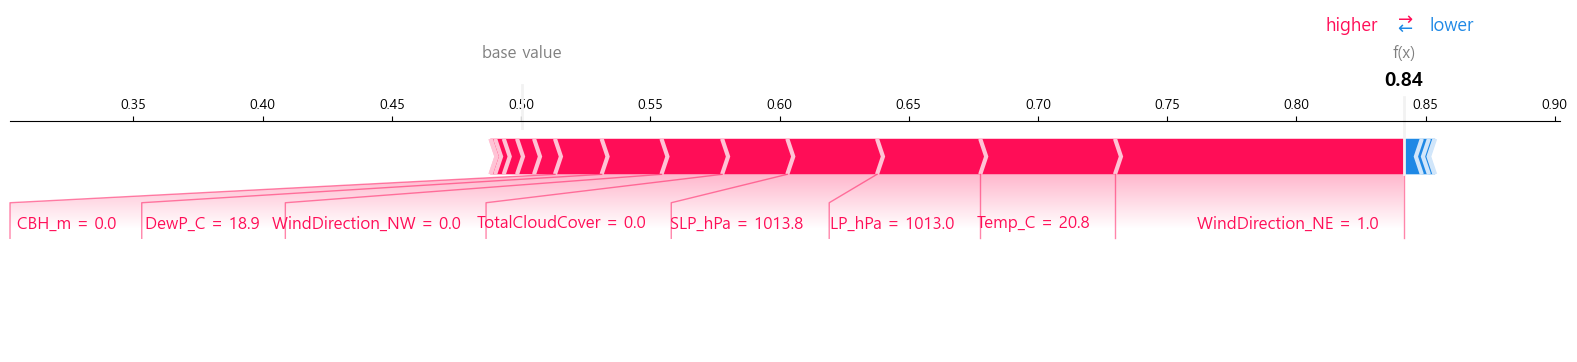

Class 1 (지연)에 대한 SHAP Force Plot


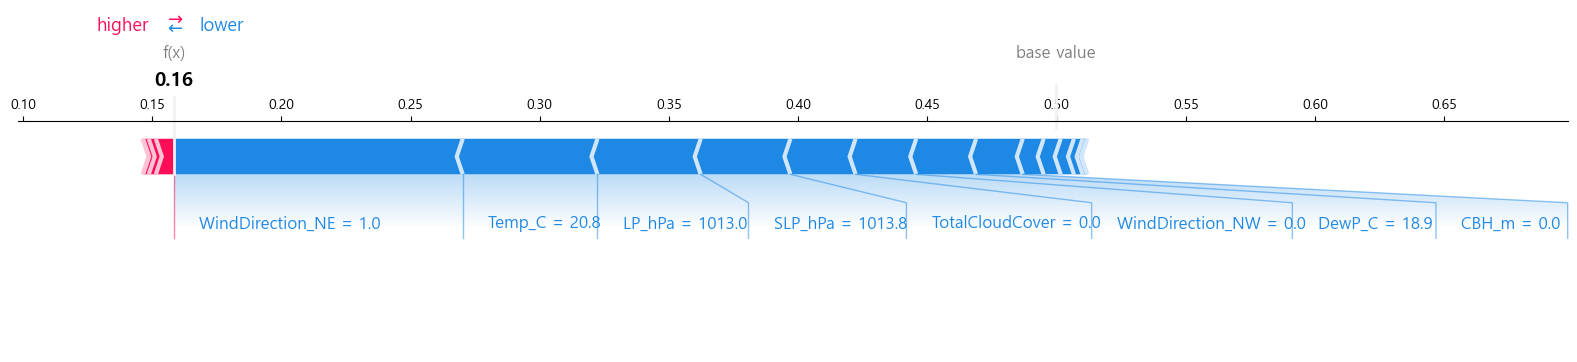

In [62]:
# Force Plot 생성 (원본 데이터 전체 사용)
for i, class_name in enumerate(['출발', '지연']):
    print(f"Class {i} ({class_name})에 대한 SHAP Force Plot")
    shap.force_plot(
        explainer.expected_value[i],              # 클래스별 기대값
        shap_values[0, :, i],                     # 첫 번째 샘플의 피처별 SHAP 값 (수정)
        X_test_kfold_df.iloc[0, :],               # 첫 번째 샘플의 피처 값
        feature_names=X_test_kfold_df.columns,    # 피처 이름
        matplotlib=True                           # Matplotlib을 사용한 시각화
    )

📊 Generating SHAP Dependence Plot for: WindSpeed_KT (Unique Values: 30)


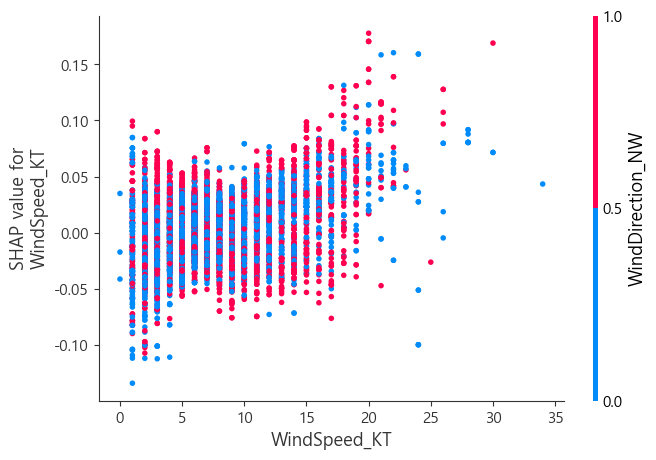

📊 Generating SHAP Dependence Plot for: Visibility_m (Unique Values: 31)


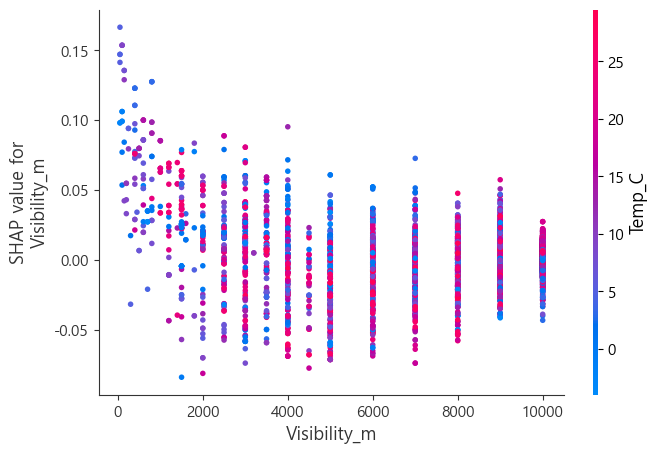

📊 Generating SHAP Dependence Plot for: Temp_C (Unique Values: 468)


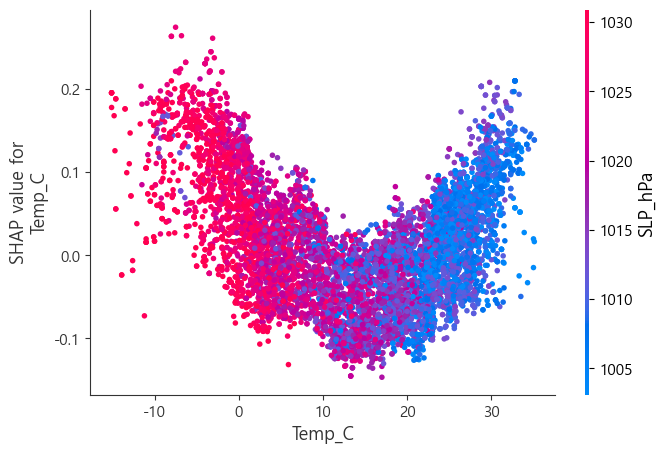

📊 Generating SHAP Dependence Plot for: DewP_C (Unique Values: 482)


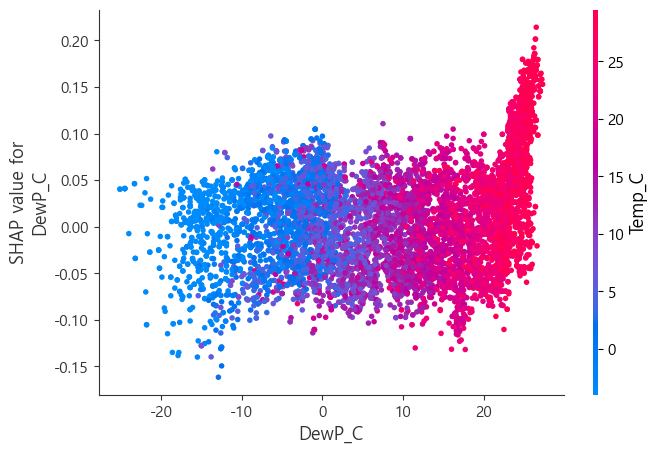

📊 Generating SHAP Dependence Plot for: SLP_hPa (Unique Values: 432)


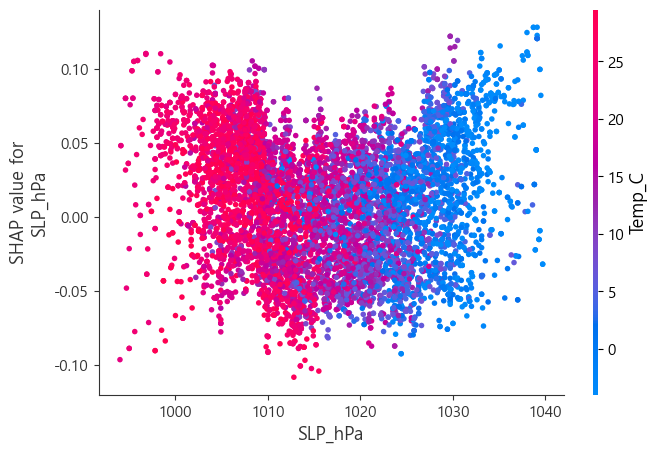

📊 Generating SHAP Dependence Plot for: LP_hPa (Unique Values: 431)


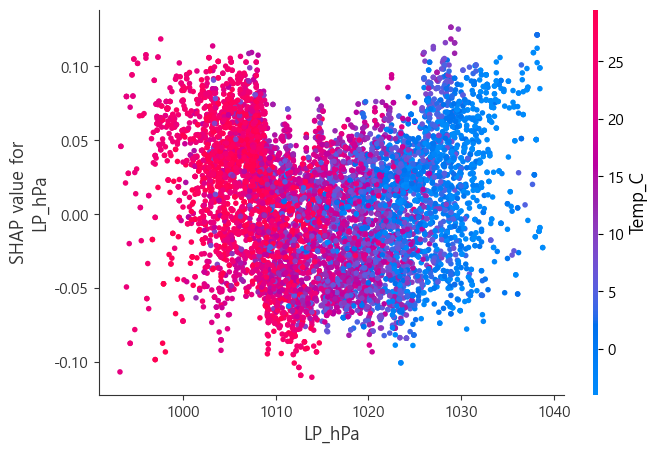

📊 Generating SHAP Dependence Plot for: Precipitation_mm (Unique Values: 90)


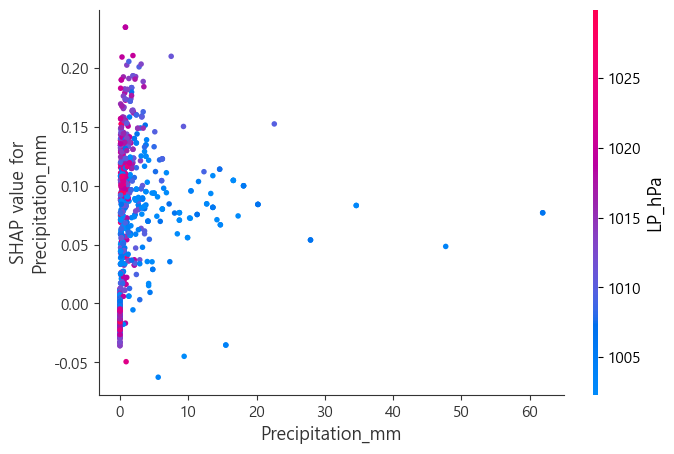

📊 Generating SHAP Dependence Plot for: CBH_m (Unique Values: 236)


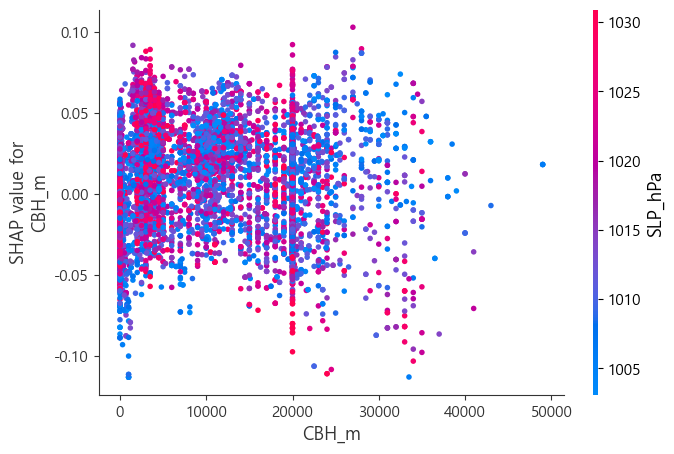

In [64]:
# 피처 리스트 정의
feature_names = airplane.drop(columns=['DelayStatus']).columns

# 고유값 10개 이상인 피처에 대해서만 dependence plot 생성
for feature in feature_names:
    unique_values = X_test_kfold_df[feature].nunique()
    
    if unique_values >= 10:
        print(f"📊 Generating SHAP Dependence Plot for: {feature} (Unique Values: {unique_values})")
        shap.dependence_plot(
            feature,                       # X축: 현재 피처
            shap_values[:, :, 1],          # '지연' 클래스에 대한 SHAP 값
            X_test_kfold_df,               # 입력 데이터
            feature_names=feature_names,    # 피처 이름
            
        )
        plt.show()  # 플롯 출력
